In [4]:
from ultralytics import YOLO
import pandas as pd

## Pose Estimation and Preparing Dataset

In [5]:
source="squat2.mov"  # Sample image for testing
model = YOLO("yolo11n-pose.pt")
class_names = model.names  # Store model classes names
results = model(source=source, stream=True)

In [6]:
KEYPOINT_NAMES = [
    'Nose', 'Left Eye', 'Right Eye', 'Left Ear', 'Right Ear',
    'Left Shoulder', 'Right Shoulder', 'Left Elbow', 'Right Elbow',
    'Left Wrist', 'Right Wrist', 'Left Hip', 'Right Hip',
    'Left Knee', 'Right Knee', 'Left Ankle', 'Right Ankle'
]

data = []

for result in results:
    kpt_list = result.keypoints.xy                 # keypoints for all objects
    kpt = kpt_list[0]
    
    frame_data = []
    for x, y in kpt.tolist(): 
        frame_data.append((x, y))
    
    data.append(frame_data)
    


video 1/1 (frame 1/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 95.9ms
video 1/1 (frame 1/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 95.9ms
video 1/1 (frame 2/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 193.1ms
video 1/1 (frame 2/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 193.1ms
video 1/1 (frame 3/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 131.6ms
video 1/1 (frame 3/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 131.6ms
video 1/1 (frame 4/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 66.8ms
video 1/1 (frame 4/81) /Users/zhantian/Documents/G

In [7]:
df = pd.DataFrame(data)
df.columns = KEYPOINT_NAMES
df.head()

,Nose,Left Eye,Right Eye,Left Ear,Right Ear,Left Shoulder,Right Shoulder,Left Elbow,Right Elbow,Left Wrist,Right Wrist,Left Hip,Right Hip,Left Knee,Right Knee,Left Ankle,Right Ankle
0,"(557.370849609375, 635.5557861328125)","(556.905029296875, 616.091064453125)","(538.6420288085938, 620.564208984375)","(517.7963256835938, 622.4647216796875)","(483.10223388671875, 636.97314453125)","(443.1387939453125, 712.1187133789062)","(465.0188903808594, 726.8720703125)","(556.0472412109375, 775.4827880859375)","(632.297119140625, 792.9031372070312)","(684.8699951171875, 813.5684204101562)","(797.6239624023438, 800.5406494140625)","(277.8878479003906, 972.45263671875)","(286.3826904296875, 984.4482421875)","(524.1817626953125, 1014.2344970703125)","(537.5333862304688, 1036.146240234375)","(413.15655517578125, 1234.260986328125)","(400.5293884277344, 1266.3978271484375)"
1,"(556.8175048828125, 641.437255859375)","(555.1422119140625, 622.338134765625)","(538.3451538085938, 626.294921875)","(513.3493041992188, 629.3623046875)","(481.9368591308594, 642.9439697265625)","(441.583740234375, 720.4677734375)","(460.8661804199219, 734.2348022460938)","(552.1937255859375, 780.4487915039062)","(626.2794799804688, 796.90185546875)","(673.1234741210938, 820.1248168945312)","(792.1306762695312, 806.2035522460938)","(275.2459716796875, 982.3201904296875)","(281.79876708984375, 994.13671875)","(526.183837890625, 1017.2490844726562)","(536.9606323242188, 1039.3790283203125)","(409.547119140625, 1237.3101806640625)","(398.0262145996094, 1269.74365234375)"
2,"(556.8065185546875, 641.1422729492188)","(555.0614624023438, 622.0306396484375)","(538.3154296875, 626.0447387695312)","(513.1577758789062, 629.1016845703125)","(481.97528076171875, 642.8782958984375)","(441.4325256347656, 720.4154663085938)","(461.0107727050781, 734.291259765625)","(552.1318359375, 780.4962158203125)","(626.2627563476562, 797.016845703125)","(672.8821411132812, 820.072021484375)","(792.0431518554688, 806.2855224609375)","(274.7429504394531, 982.275390625)","(281.5458068847656, 994.1067504882812)","(525.6222534179688, 1017.2080688476562)","(536.8746337890625, 1039.3709716796875)","(409.17584228515625, 1237.2779541015625)","(398.10882568359375, 1269.9066162109375)"
3,"(555.0630493164062, 645.8919677734375)","(552.6212768554688, 626.4457397460938)","(536.7587280273438, 630.6005249023438)","(508.9921569824219, 632.8035278320312)","(481.7401428222656, 647.4368286132812)","(436.5721740722656, 725.8275146484375)","(463.99481201171875, 740.2366943359375)","(543.0714111328125, 784.6871337890625)","(628.9640502929688, 801.7446899414062)","(658.8727416992188, 823.3272094726562)","(788.7854614257812, 812.1322631835938)","(268.6575927734375, 987.654052734375)","(280.5472106933594, 999.3599243164062)","(522.583251953125, 1015.421142578125)","(536.6854858398438, 1037.45263671875)","(404.916748046875, 1237.2630615234375)","(395.5157775878906, 1270.6884765625)"
4,"(555.0768432617188, 645.8630981445312)","(552.6314697265625, 626.4022827148438)","(536.7813110351562, 630.5499267578125)","(509.02825927734375, 632.7671508789062)","(481.77972412109375, 647.3595581054688)","(436.70355224609375, 725.9273681640625)","(463.9471740722656, 740.1717529296875)","(543.335693359375, 784.8538818359375)","(628.8597412109375, 801.7175903320312)","(659.114013671875, 823.2167358398438)","(788.8299560546875, 812.2050170898438)","(268.5627746582031, 987.6630249023438)","(280.36590576171875, 999.2997436523438)","(522.4346313476562, 1015.5676879882812)","(536.7295532226562, 1037.51708984375)","(404.71112060546875, 1237.474853515625)","(395.676025390625, 1270.931640625)"


---

## Analyzing and Building Lags

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#### In order to access individual x and y data of each keypoint, we need to seperate (x, y) and assign them to their own column

In [ ]:
#https://stackoverflow.com/questions/10867882/how-are-tuples-unpacked-in-for-loops

rows = []
for frame_data in data:
    row = {}
    for i, (x, y) in enumerate(frame_data):
        keypoint_name = KEYPOINT_NAMES[i]
        row[f'{keypoint_name} x'] = x
        row[f'{keypoint_name} y'] = y
    rows.append(row)

df = pd.DataFrame(rows)
df.head(20)

,Nose x,Nose y,Left Eye x,Left Eye y,Right Eye x,Right Eye y,Left Ear x,Left Ear y,Right Ear x,Right Ear y,...,Right Hip x,Right Hip y,Left Knee x,Left Knee y,Right Knee x,Right Knee y,Left Ankle x,Left Ankle y,Right Ankle x,Right Ankle y
0,557.370850,635.555786,556.905029,616.091064,538.642029,620.564209,517.796326,622.464722,483.102234,636.973145,...,286.382690,984.448242,524.181763,1014.234497,537.533386,1036.146240,413.156555,1234.260986,400.529388,1266.397827
1,556.817505,641.437256,555.142212,622.338135,538.345154,626.294922,513.349304,629.362305,481.936859,642.943970,...,281.798767,994.136719,526.183838,1017.249084,536.960632,1039.379028,409.547119,1237.310181,398.026215,1269.743652
2,556.806519,641.142273,555.061462,622.030640,538.315430,626.044739,513.157776,629.101685,481.975281,642.878296,...,281.545807,994.106750,525.622253,1017.208069,536.874634,1039.370972,409.175842,1237.277954,398.108826,1269.906616
3,555.063049,645.891968,552.621277,626.445740,536.758728,630.600525,508.992157,632.803528,481.740143,647.436829,...,280.547211,999.359924,522.583252,1015.421143,536.685486,1037.452637,404.916748,1237.263062,395.515778,1270.688477
4,555.076843,645.863098,552.631470,626.402283,536.781311,630.549927,509.028259,632.767151,481.779724,647.359558,...,280.365906,999.299744,522.434631,1015.567688,536.729553,1037.517090,404.711121,1237.474854,395.676025,1270.931641
5,554.655762,650.509827,551.527893,631.082336,536.765137,635.264282,506.555389,637.075989,482.195557,651.949036,...,280.803650,1005.530090,522.974670,1012.197388,538.611389,1035.226074,404.642029,1235.118652,395.717163,1268.347046
6,554.671509,650.490051,551.549377,631.094788,536.804688,635.246521,506.607635,637.129517,482.236145,651.907898,...,280.834686,1005.381714,523.186523,1012.190735,538.404358,1035.138672,405.565887,1235.123413,396.039490,1268.235718
7,552.303833,656.908813,551.055359,636.560120,533.846191,640.371155,510.100281,641.434448,478.438721,654.634216,...,278.439301,1011.013123,529.631714,1010.096741,544.562256,1032.530640,409.120697,1237.639526,400.594482,1268.176758
8,552.285522,656.877441,551.025879,636.545410,533.822144,640.354004,510.096100,641.441406,478.398132,654.618469,...,278.378693,1011.005737,529.624084,1010.023865,544.442688,1032.428223,409.086395,1237.536377,400.570740,1268.091309
9,551.230591,659.013245,550.075439,639.252319,532.017456,642.765747,510.807129,646.179138,476.295380,658.810852,...,277.821381,1015.545471,531.861389,1011.159973,543.789062,1033.147583,410.063416,1237.591431,402.477203,1267.710083


#### Let's use Right Knee's y position as an example

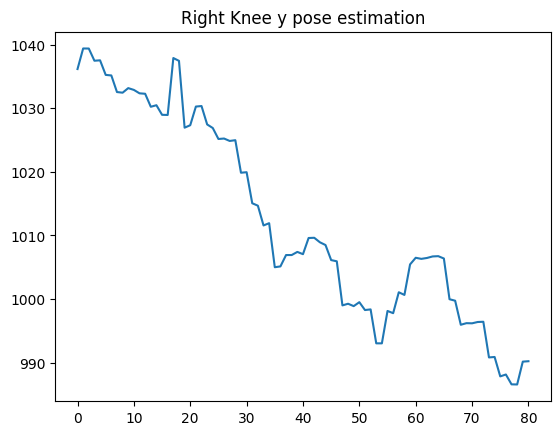

In [10]:
plt.plot(df['Right Knee y'])
plt.title("Right Knee y pose estimation")
plt.show()

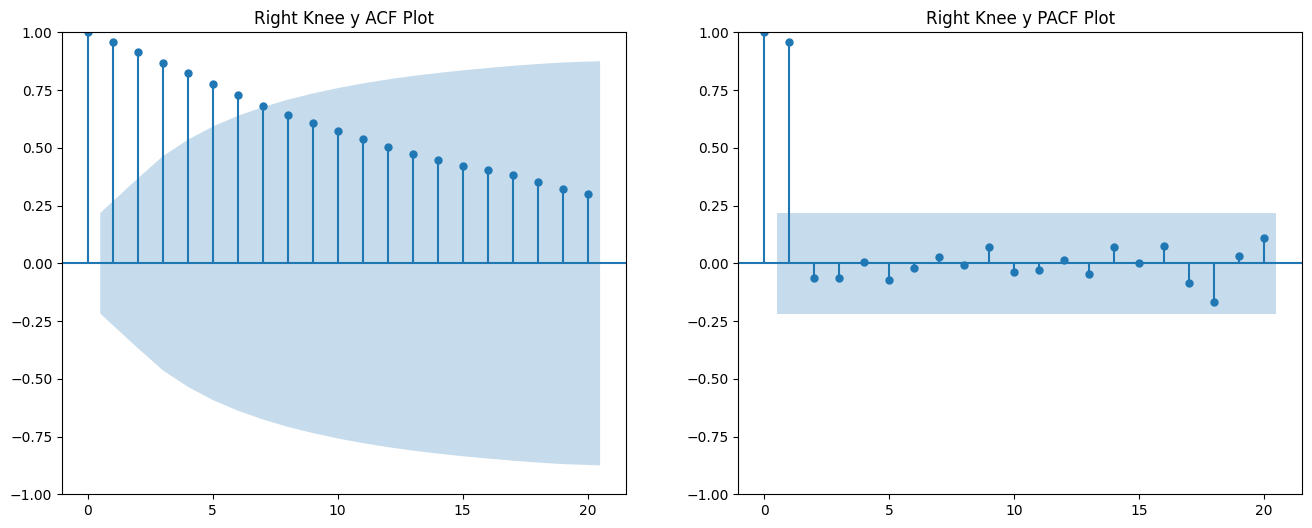

In [11]:
# Plot ACF and PACF to visualize the optimal lag
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF plot
plot_acf(df['Right Knee y'], ax=axes[0], lags=20)
axes[0].set_title('Right Knee y ACF Plot')

# PACF plot
plot_pacf(df['Right Knee y'], ax=axes[1], lags=20, method='ywm')
axes[1].set_title('Right Knee y PACF Plot')

plt.show()

In [12]:
#https://www.geeksforgeeks.org/machine-learning/what-is-lag-in-time-series-forecasting/

# Function to fit ARIMA models with different p (lags) and return AIC scores
def select_best_lag(right_knee_y, max_lag):
    aic_values = []
    
    for p in range(1, max_lag + 1):
        model = ARIMA(right_knee_y, order=(p, 0, 0))  # ARIMA(p, d, q) where d=0 for AR model
        model_fit = model.fit()
        aic_values.append((p, model_fit.aic))
        
    return aic_values

# Set max_lag to try and get the best lag based on AIC
max_lag = 10
aic_scores = select_best_lag(df['Right Knee y'], max_lag)

# Print the AIC values for different lags
for lag, aic in aic_scores:
    print(f'Lag: {lag}, AIC: {aic}')

# Find the lag with the minimum AIC value
best_lag = min(aic_scores, key=lambda x: x[1])[0]
print(f'\nOptimal Lag based on AIC: {best_lag}')

Lag: 1, AIC: 405.5416577146636
Lag: 2, AIC: 407.5423218700018
Lag: 3, AIC: 409.5319492885089
Lag: 4, AIC: 411.5311602310556
Lag: 5, AIC: 410.82049815884915
Lag: 6, AIC: 412.381782051844
Lag: 7, AIC: 414.3813640853911
Lag: 8, AIC: 416.2440049397467
Lag: 9, AIC: 417.67758934643524
Lag: 10, AIC: 419.62841665638007

Optimal Lag based on AIC: 1


## Create Lags

In [13]:
def make_lags(ts, lags): # https://www.kaggle.com/code/ryanholbrook/time-series-as-features
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(1, lags + 1)
        },
        axis=1)


---

## Implementing and Comparing Forecasting Strategy

### Recursive Forecasting

In [14]:
steps = 6
data_train = df['Right Knee y'][:-steps]
data_test  = df['Right Knee y'][-steps:]


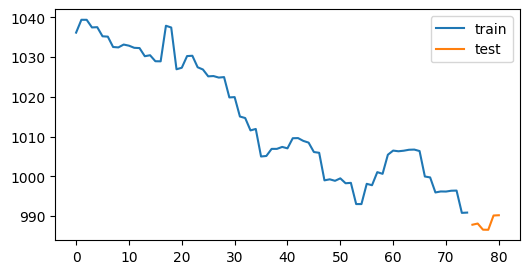

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
ax.legend()

In [16]:
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor
from skforecast.preprocessing import RollingFeatures


forecaster = ForecasterRecursive(
                 regressor       = LGBMRegressor(random_state=123, verbose=-1),
                 lags            = 6, ## 6 was chosen according to the ACF graph above
                 window_features = RollingFeatures(stats=['mean'], window_sizes=10),
                 transformer_y   = None, 
             )

forecaster.fit(y=data_train, store_in_sample_residuals=True)

# Predict the next 6 steps
predictions = forecaster.predict(steps=6)
print("Future predictions for frames 83-88:")
print(predictions)

/Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Future predictions for frames 83-88:
75    997.504772
76    997.504772
77    997.504772
78    997.504772
79    997.504772
80    997.504772
Name: pred, dtype: float64


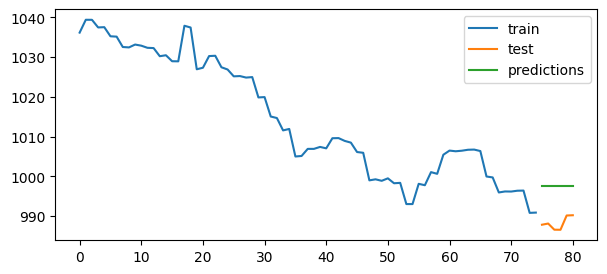

In [17]:
predictions = forecaster.predict(steps=6)

fig, ax = plt.subplots(figsize=(7, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend()

#### The recursive forecasting is quite inaccurate and errors will accumulate, let's try a different strategy

### Direct Multi-Step Forecasting

In [18]:
def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)


right_knee_y_lag = make_lags(df['Right Knee y'], 6) # 6 was chosen according to the ACF graph above
right_knee_y_lag.head()

,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6
0,NaN,NaN,NaN,NaN,NaN,NaN
1,1036.146240,NaN,NaN,NaN,NaN,NaN
2,1039.379028,1036.146240,NaN,NaN,NaN,NaN
3,1039.370972,1039.379028,1036.146240,NaN,NaN,NaN
4,1037.452637,1039.370972,1039.379028,1036.14624,NaN,NaN


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Create target series and data splits
X = right_knee_y_lag
X = X.dropna() 
y = df['Right Knee y'].copy()
y = make_multistep_target(df['Right Knee y'], steps=6).dropna()

y, X = y.align(X, join='inner', axis=0)

# Train on frames up to 74, test on frames 75-80, because the lag is 6
split_point = 74

X_train = X.loc[:split_point]
X_test = X.loc[split_point+1:]
y_train = y.loc[:split_point]
y_test = y.loc[split_point+1:]

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

model = MultiOutputRegressor(XGBRegressor())
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [21]:
predictions_75_80 = pd.Series(dtype=float, name='Right Knee y')

for target_frame in range(75, 81):
    source_frame = target_frame - 6  # 6 steps back
    if source_frame in X_train.index:
        predictions_75_80[target_frame] = y_fit.loc[source_frame, 'y_step_6']

print("Predictions for frames 75-80:")
print(predictions_75_80)

Predictions for frames 75-80:
75    990.882080
76    987.831299
77    988.127380
78    986.581299
79    986.559631
80    990.151428
Name: Right Knee y, dtype: float32


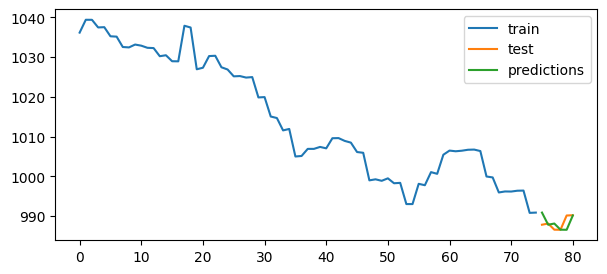

In [22]:
fig, ax = plt.subplots(figsize=(7, 3))
df['Right Knee y'].loc[:74].plot(ax=ax, label='train')
df['Right Knee y'].loc[75:80].plot(ax=ax, label='test')
predictions_75_80.plot(ax=ax, label='predictions')
ax.legend()

#### Multi-step forecasting is much more accurate and efficient than recursive forecast, so now let's apply this method to forecasting of all key points.

---

## Replicate the forecasting strategy on all keypoints

#### In order to forecast the same amount of frame for every keypoints, we need to choose a single universal lag due to the limitations of the Multi-step Forecasting strategy we are using.

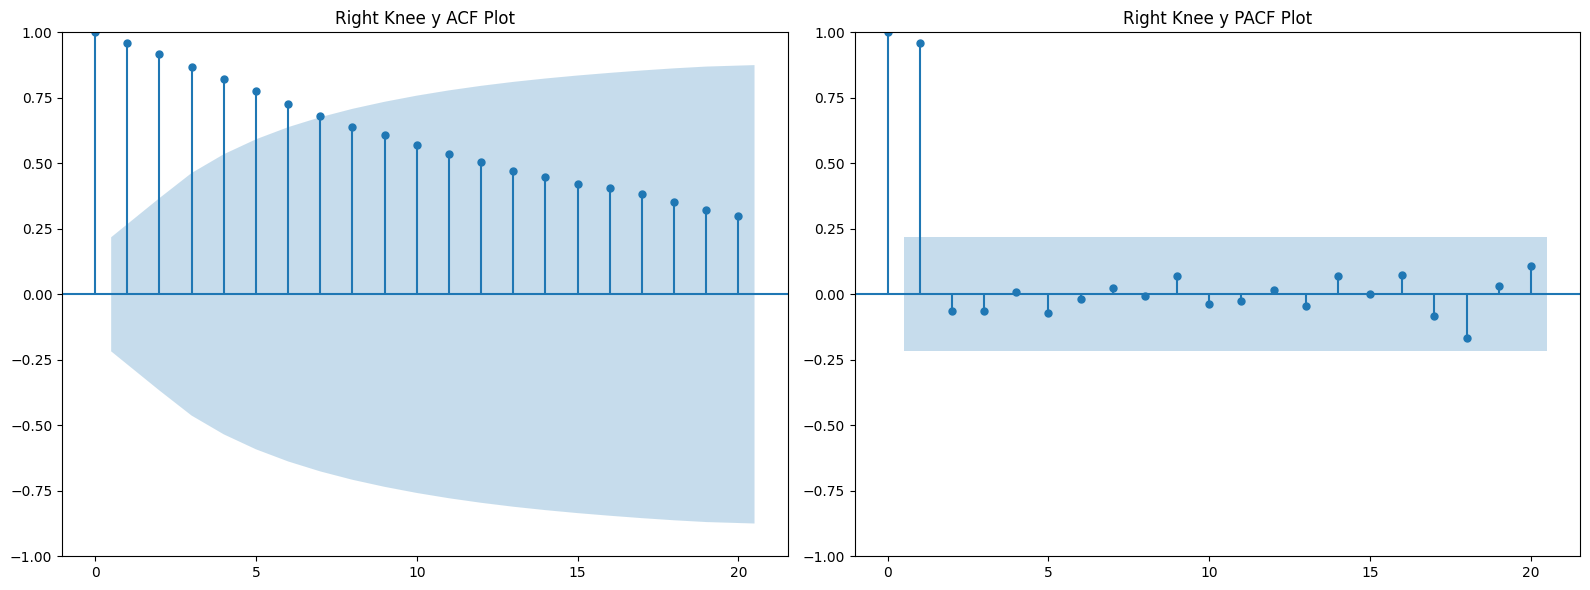

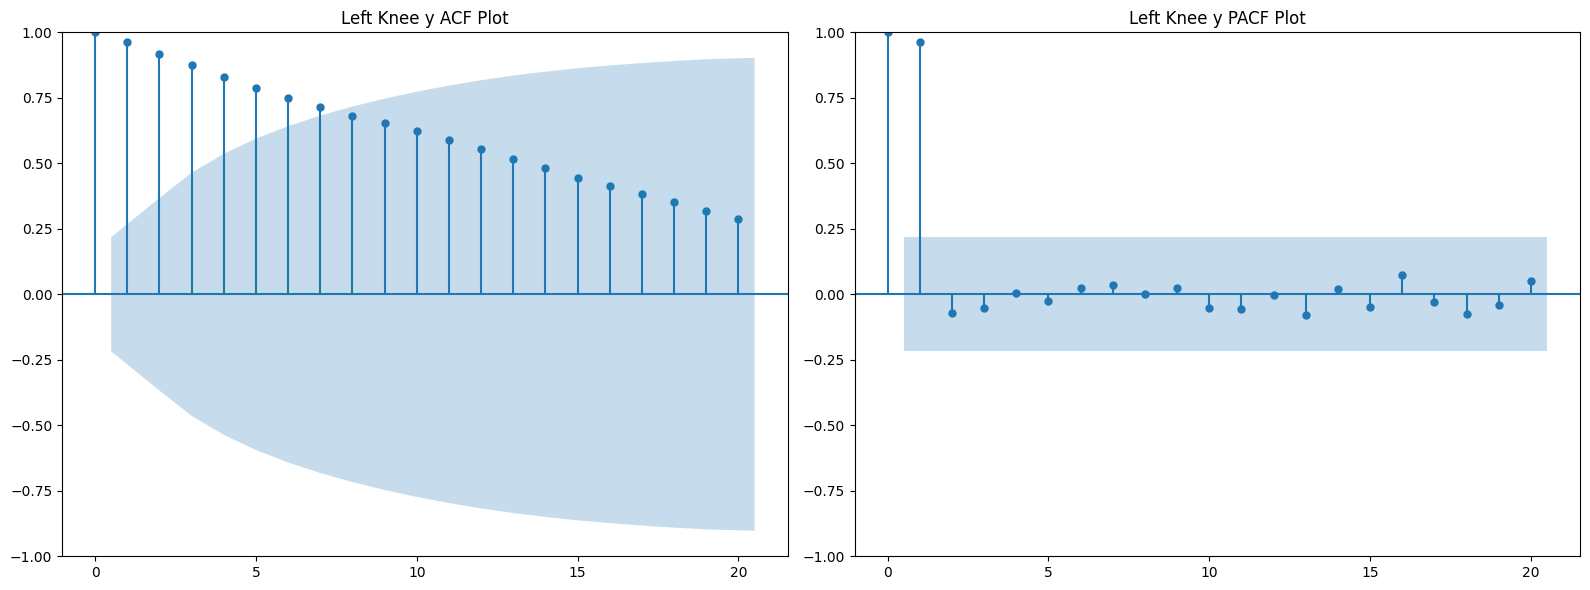

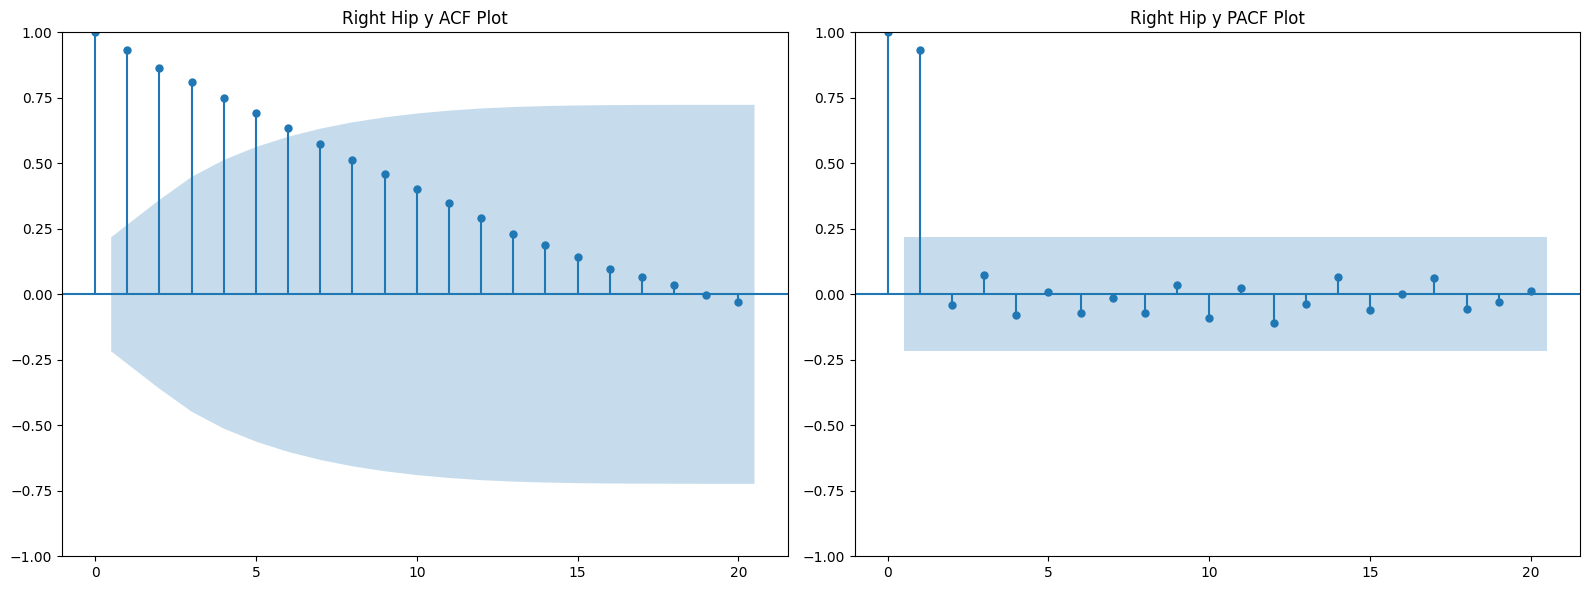

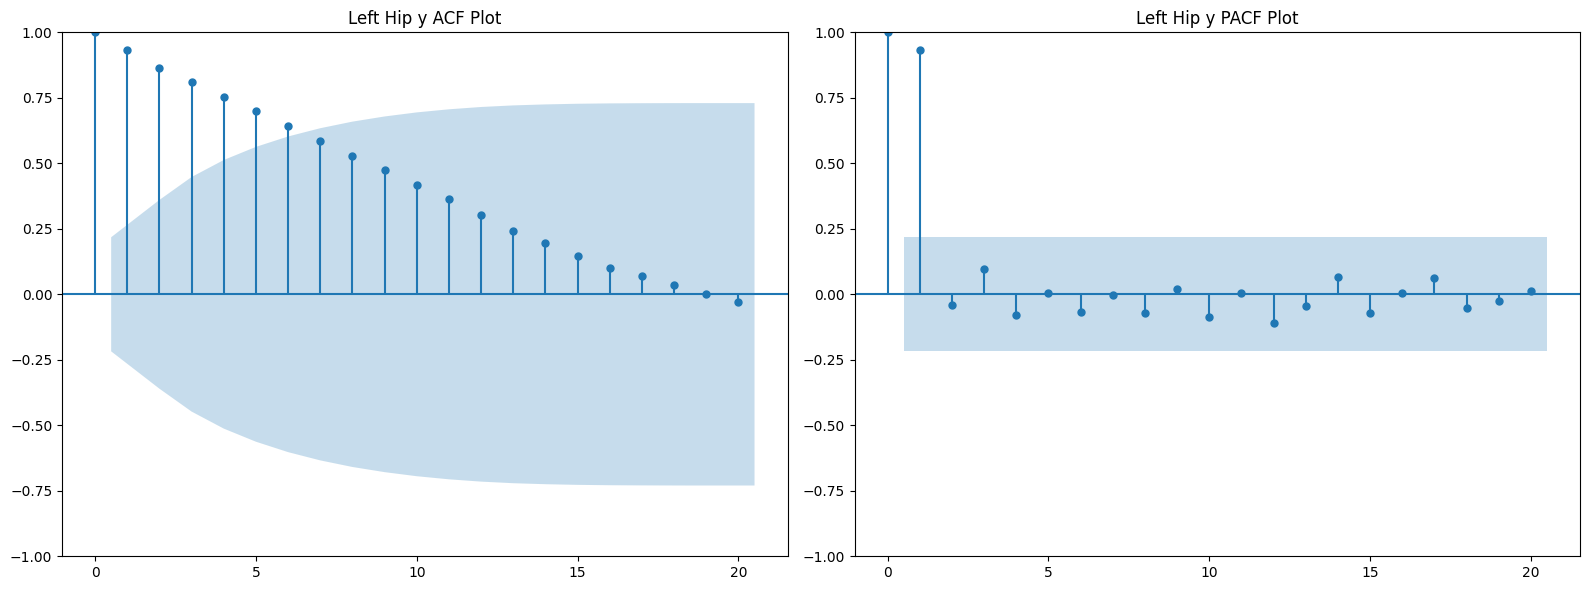

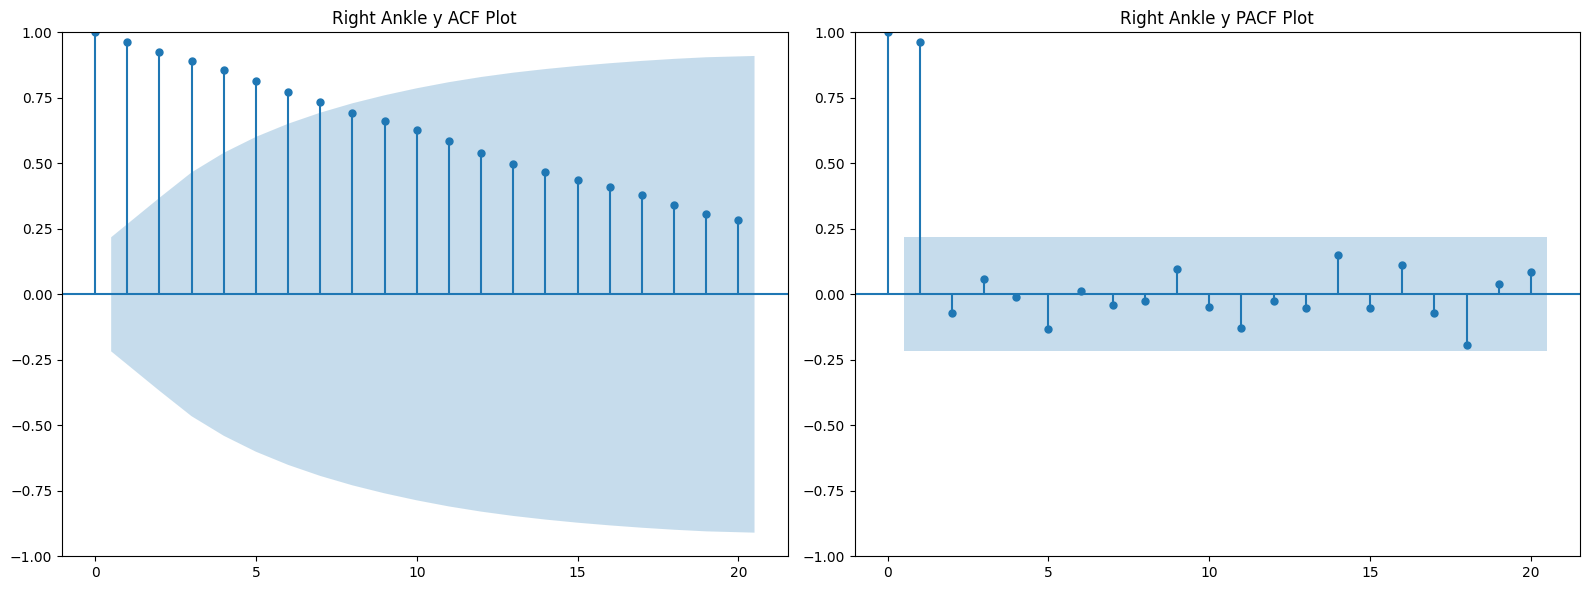

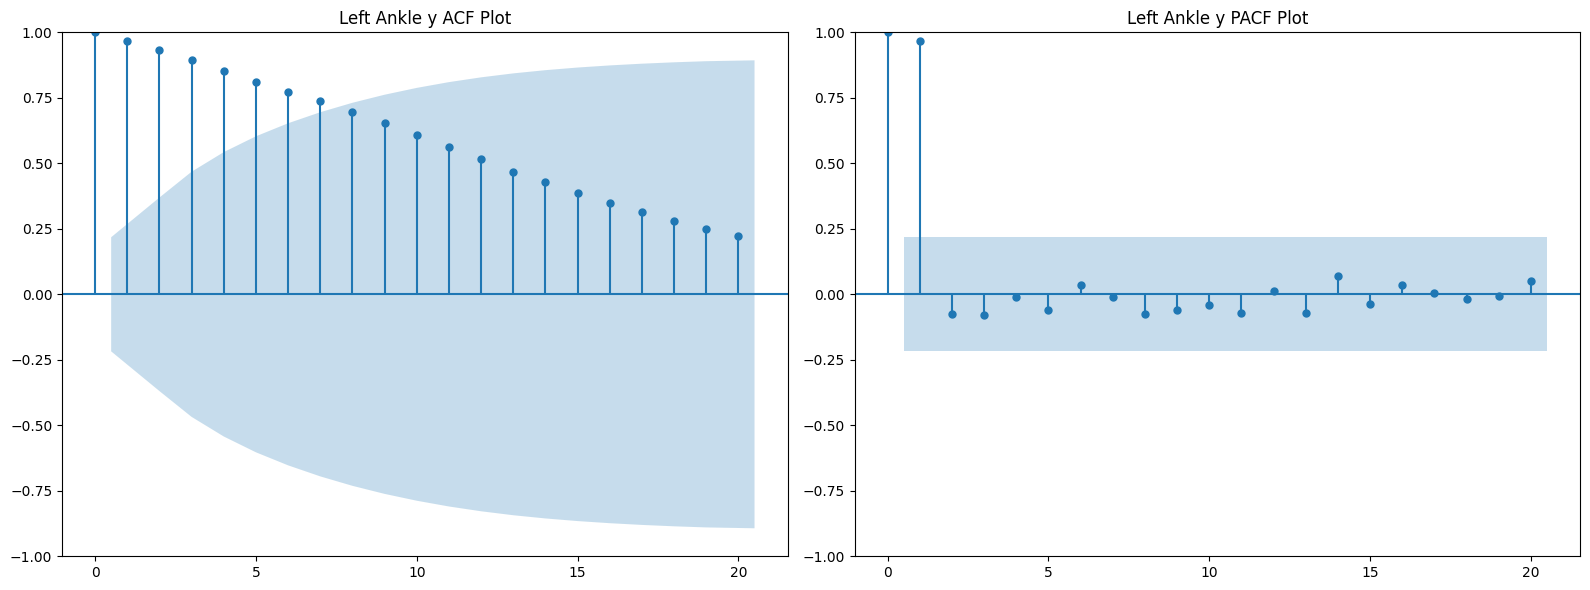

In [23]:
# These keypoints were chosen to alayze because to analyze they are the key points that are most important and move the most
keypoints_to_analyze = [
    'Right Knee y',
    'Left Knee y', 
    'Right Hip y',
    'Left Hip y',
    'Right Ankle y',
    'Left Ankle y'
]

# Plot ACF and PACF for each keypoint
for keypoint in keypoints_to_analyze:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ACF plot
    plot_acf(df[keypoint], ax=axes[0], lags=20)
    axes[0].set_title(f'{keypoint} ACF Plot')
    
    # PACF plot
    plot_pacf(df[keypoint], ax=axes[1], lags=20, method='ywm')
    axes[1].set_title(f'{keypoint} PACF Plot')
    
    plt.tight_layout()
    plt.show()

#### Based on the above results, we could reuse the lag 6 now for every keypoints

In [24]:
lag = 6
steps = 6
split_point = 74

# Dictionary to store predictions for each coordinate
all_predictions = {}

for coord in df.columns:
    coord_lag = make_lags(df[coord], lag)
    
    X = coord_lag.dropna()
    y = make_multistep_target(df[coord], steps=steps).dropna()
    y, X = y.align(X, join='inner', axis=0)
    
    # Split data
    X_train = X.loc[:split_point]
    y_train = y.loc[:split_point]
    
    # Train model
    model = MultiOutputRegressor(XGBRegressor(random_state=123))
    model.fit(X_train, y_train)
    
    # Generate predictions
    y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
    
    predictions = pd.Series(dtype=float, name=coord)
    for target_frame in range(75, 81):
        source_frame = target_frame - steps
        if source_frame in X_train.index:
            predictions[target_frame] = y_fit.loc[source_frame, f'y_step_{steps}']
    
    all_predictions[coord] = predictions

# Convert to DataFrame
predictions_df = pd.DataFrame(all_predictions)
predictions_df.head()

,Nose x,Nose y,Left Eye x,Left Eye y,Right Eye x,Right Eye y,Left Ear x,Left Ear y,Right Ear x,Right Ear y,...,Right Hip x,Right Hip y,Left Knee x,Left Knee y,Right Knee x,Right Knee y,Left Ankle x,Left Ankle y,Right Ankle x,Right Ankle y
75,566.537354,541.283386,562.137451,518.890381,547.958435,522.533386,510.326416,518.906921,484.059174,531.573669,...,348.074127,892.732605,526.571777,967.336487,539.342346,990.882080,400.276276,1185.533203,401.966095,1224.082153
76,560.344849,518.732056,554.712341,496.808167,542.446777,500.280212,500.602386,497.341888,478.352448,509.306854,...,345.118011,879.285400,520.484619,962.249695,535.307800,987.831299,397.152374,1183.618896,402.071503,1223.219971
77,560.277222,518.591492,554.582336,496.712524,542.376099,500.239563,500.424774,497.320465,478.398499,509.436676,...,345.294708,879.201294,520.585327,962.377869,535.350403,988.127380,397.172028,1183.520874,401.928497,1223.370728
78,563.738586,497.857880,560.266052,476.544495,542.097717,480.269440,513.821533,481.942596,473.051697,493.816833,...,346.839508,866.168518,529.636658,961.667725,532.954956,986.581299,399.315247,1184.323608,401.610138,1225.316284
79,563.734680,497.828003,560.171204,476.483734,542.127930,480.223511,513.468872,481.789764,473.106689,493.743713,...,346.983521,866.311401,529.415955,961.571472,533.146057,986.559631,399.311493,1184.190430,401.514648,1225.215820


---

## Visualize the forcasting results

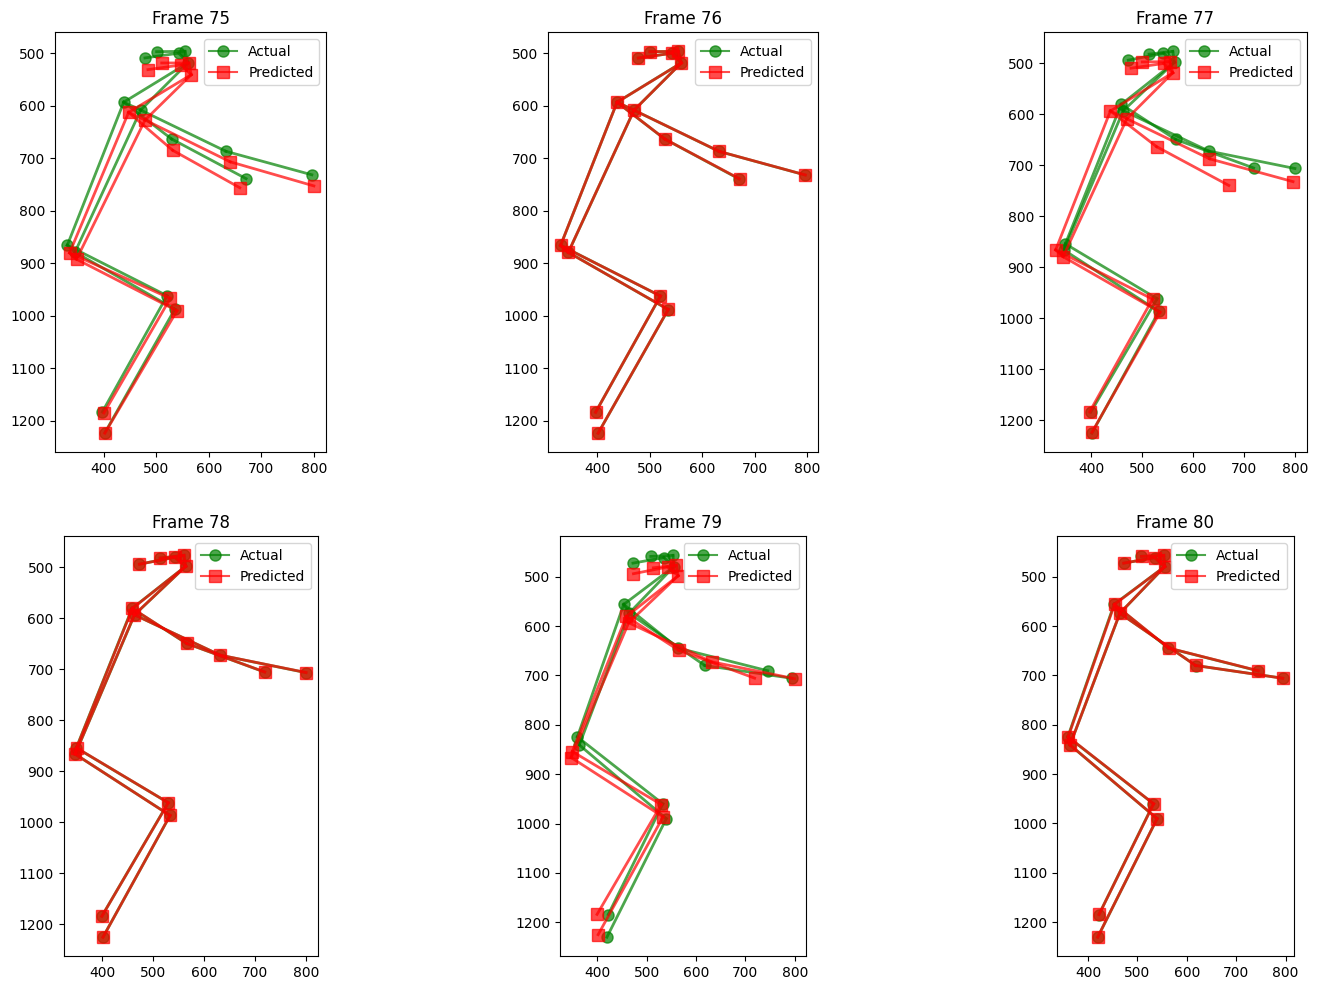

In [ ]:
import matplotlib.pyplot as plt

# Manually define skeleton connections
SKELETON_CONNECTIONS = [
    ('Nose', 'Left Eye'), ('Nose', 'Right Eye'),
    ('Left Eye', 'Left Ear'), ('Right Eye', 'Right Ear'),
    ('Nose', 'Left Shoulder'), ('Nose', 'Right Shoulder'),
    ('Left Shoulder', 'Right Shoulder'),
    ('Left Shoulder', 'Left Elbow'), ('Left Elbow', 'Left Wrist'),
    ('Right Shoulder', 'Right Elbow'), ('Right Elbow', 'Right Wrist'),
    ('Left Shoulder', 'Left Hip'), ('Right Shoulder', 'Right Hip'),
    ('Left Hip', 'Right Hip'),
    ('Left Hip', 'Left Knee'), ('Left Knee', 'Left Ankle'),
    ('Right Hip', 'Right Knee'), ('Right Knee', 'Right Ankle')
]

def plot_skeleton(frame_data, ax, title, color='blue', marker='o', alpha=1.0, label=None):
    # draw first keypoint with label for legend
    first_kp = KEYPOINT_NAMES[0]
    x = frame_data[f'{first_kp} x']
    y = frame_data[f'{first_kp} y']
    ax.plot(x, y, marker=marker, color=color, markersize=8, alpha=alpha, label=label)
    
    # plot remaining keypoints
    for kp in KEYPOINT_NAMES[1:]:
        x = frame_data[f'{kp} x']
        y = frame_data[f'{kp} y']
        ax.plot(x, y, marker=marker, color=color, markersize=8, alpha=alpha)
    
    # draw skeleton connections
    for start, end in SKELETON_CONNECTIONS:
        x_start = frame_data[f'{start} x']
        y_start = frame_data[f'{start} y']
        x_end = frame_data[f'{end} x']
        y_end = frame_data[f'{end} y']
        ax.plot([x_start, x_end], [y_start, y_end], color=color, linewidth=2, alpha=alpha)
    
    ax.set_title(title)
    ax.set_aspect('equal')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# loop through every frame
for i, frame in enumerate(range(75, 81)):
    ax = axes[i]
    
    # Plot actual keypoints
    actual_data = df.loc[frame]
    plot_skeleton(actual_data, ax, f'Frame {frame}', color='green', alpha=0.7, label='Actual')
    
    # Plot predicted keypoints
    pred_data = predictions_df.loc[frame]
    plot_skeleton(pred_data, ax, f'Frame {frame}', color='red', marker='s', alpha=0.7, label='Predicted')
    
    ax.invert_yaxis()
    ax.legend()

plt.show()